In [2]:
# =============================================================================
# SETUP & IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Paths
DIRPATH = '/Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data'
STATA_DATA = f'{DIRPATH}/stata_data'
FIGURES = f'{DIRPATH}/figures'

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✓ Base imports loaded")

✓ Base imports loaded


In [3]:
# =============================================================================
# INSTALL ECONML (if needed)
# =============================================================================

try:
    from econml.dml import CausalForestDML
    from econml.cate_interpreter import SingleTreeCateInterpreter
    print("✓ EconML already installed")
except ImportError:
    print("Installing EconML...")
    !pip install econml -q
    from econml.dml import CausalForestDML
    from econml.cate_interpreter import SingleTreeCateInterpreter
    print("✓ EconML installed")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("✓ All ML imports loaded")

Installing EconML...
✓ EconML installed
✓ All ML imports loaded


---
## 1. Data Preparation

In [5]:
# =============================================================================
# LOAD DATA
# =============================================================================

data = pd.read_stata(f'{STATA_DATA}/data_regressions_passthrough.dta')
print(f"✓ Data loaded: {len(data):,} observations")
print(f"  Period: {data['year'].min():.0f} - {data['year'].max():.0f}")

# Show available columns
print(f"\n📊 Available variables ({len(data.columns)}):")
print(sorted(data.columns.tolist()))

✓ Data loaded: 30,648 observations
  Period: 2004 - 2007

📊 Available variables (45):
['brent', 'brent2', 'coal', 'coal2', 'day', 'ecost', 'ecost2', 'ecost2_off', 'ecost2_peak', 'ecost_int', 'eprice', 'erate', 'gas', 'gas2', 'hour', 'humid', 'lbrent', 'lcoal', 'lecost2_off', 'lecost2_peak', 'leprice', 'lgas', 'lmg_price', 'ltotalcost2_off', 'ltotalcost2_peak', 'mg_price', 'month', 'peak', 'rd', 'temp', 'temp2', 'tempx', 'time', 'totalcost', 'totalcost2', 'totalcost2_off', 'totalcost2_peak', 'weekd', 'windtime', 'windx', 'windx2', 'yb', 'year', 'ym', 'yq']


In [6]:
# =============================================================================
# PREPARE VARIABLES FOR CAUSAL FOREST
# =============================================================================

# Define variables
outcome_var = 'mg_price'      # Y: Electricity price
treatment_var = 'eprice'       # T: CO2 price (continuous treatment)

# Heterogeneity variables (X) - what drives variation in treatment effect?
hetero_vars = ['hour', 'month', 'year', 'weekday']

# Add wind if available
wind_candidates = ['windx', 'wind', 'wind_speed', 'renewable']
for wc in wind_candidates:
    if wc in data.columns:
        hetero_vars.append(wc)
        print(f"✓ Found wind variable: {wc}")
        break

# Add load/demand if available
load_candidates = ['load', 'demand', 'totalload', 'q_total']
for lc in load_candidates:
    if lc in data.columns:
        hetero_vars.append(lc)
        print(f"✓ Found load variable: {lc}")
        break

# Control variables (W)
control_vars = []
fuel_candidates = ['coal', 'gas', 'totalcost', 'fuel_price']
for fc in fuel_candidates:
    if fc in data.columns:
        control_vars.append(fc)

print(f"\n📋 Variable Setup:")
print(f"   Outcome (Y): {outcome_var}")
print(f"   Treatment (T): {treatment_var}")
print(f"   Heterogeneity (X): {hetero_vars}")
print(f"   Controls (W): {control_vars}")

✓ Found wind variable: windx

📋 Variable Setup:
   Outcome (Y): mg_price
   Treatment (T): eprice
   Heterogeneity (X): ['hour', 'month', 'year', 'weekday', 'windx']
   Controls (W): ['coal', 'gas', 'totalcost']


In [7]:
# =============================================================================
# CLEAN DATA FOR ML
# =============================================================================

# Select relevant columns
all_vars = [outcome_var, treatment_var] + hetero_vars + control_vars
all_vars = list(set(all_vars))  # Remove duplicates

# Filter to available columns
available_vars = [v for v in all_vars if v in data.columns]
df = data[available_vars].copy()

# Drop missing values
df_clean = df.dropna()
print(f"✓ Clean data: {len(df_clean):,} observations (dropped {len(df) - len(df_clean):,} with NaN)")

# Filter to period with CO2 prices (EU-ETS started 2005)
if 'year' in df_clean.columns:
    df_clean = df_clean[df_clean['year'] >= 2005]
    print(f"✓ Filtered to EU-ETS period (2005+): {len(df_clean):,} observations")

# Remove observations with zero CO2 price
df_clean = df_clean[df_clean[treatment_var] > 0]
print(f"✓ Removed zero CO2 prices: {len(df_clean):,} observations")

# Summary stats
print(f"\n📊 Summary Statistics:")
print(df_clean[[outcome_var, treatment_var]].describe().round(2))

✓ Clean data: 17,309 observations (dropped 13,339 with NaN)
✓ Filtered to EU-ETS period (2005+): 13,321 observations
✓ Removed zero CO2 prices: 13,321 observations

📊 Summary Statistics:
       mg_price    eprice
count  13321.00  13321.00
mean      43.45     15.27
std       14.66      9.05
min        1.00      0.11
25%       33.65      7.32
50%       40.00     16.60
75%       50.47     22.40
max      124.96     31.58


---
## 2. Causal Forest Estimation

In [8]:
# =============================================================================
# PREPARE MATRICES FOR CAUSAL FOREST
# =============================================================================

# Outcome
Y = df_clean[outcome_var].values

# Treatment (continuous)
T = df_clean[treatment_var].values

# Heterogeneity variables
X_vars = [v for v in hetero_vars if v in df_clean.columns]
X = df_clean[X_vars].values

# Controls
W_vars = [v for v in control_vars if v in df_clean.columns]
if len(W_vars) > 0:
    W = df_clean[W_vars].values
else:
    W = None

print(f"✓ Matrices prepared:")
print(f"   Y (outcome): {Y.shape}")
print(f"   T (treatment): {T.shape}")
print(f"   X (heterogeneity): {X.shape} - {X_vars}")
print(f"   W (controls): {W.shape if W is not None else 'None'} - {W_vars}")

✓ Matrices prepared:
   Y (outcome): (13321,)
   T (treatment): (13321,)
   X (heterogeneity): (13321, 4) - ['hour', 'month', 'year', 'windx']
   W (controls): (13321, 3) - ['coal', 'gas', 'totalcost']


In [9]:
# =============================================================================
# TRAIN CAUSAL FOREST
# =============================================================================

print("Training Causal Forest (this may take a few minutes)...")
print("="*60)

# Initialize Causal Forest with Double ML
# Uses random forests for both Y and T models (nuisance functions)
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    n_estimators=200,           # Number of trees in causal forest
    min_samples_leaf=50,        # Minimum samples per leaf
    max_depth=10,               # Max depth of trees
    cv=3,                       # Cross-validation folds
    random_state=42
)

# Fit the model
causal_forest.fit(Y, T, X=X, W=W)

print("\n✓ Causal Forest trained successfully!")

Training Causal Forest (this may take a few minutes)...

✓ Causal Forest trained successfully!


In [10]:
# =============================================================================
# ESTIMATE HETEROGENEOUS TREATMENT EFFECTS (CATE)
# =============================================================================

# Get CATE estimates for each observation
tau_hat = causal_forest.effect(X)  # Point estimates
tau_lb, tau_ub = causal_forest.effect_interval(X, alpha=0.05)  # 95% CI

# Add to dataframe
df_clean['tau_hat'] = tau_hat
df_clean['tau_lb'] = tau_lb
df_clean['tau_ub'] = tau_ub

print("="*80)
print("CAUSAL FOREST RESULTS: Heterogeneous Pass-Through Effects")
print("="*80)

print(f"\n📊 Distribution of CATE (τ̂) - Pass-Through Effect:")
print(f"   Mean τ̂: {tau_hat.mean():.4f}")
print(f"   Std τ̂:  {tau_hat.std():.4f}")
print(f"   Min τ̂:  {tau_hat.min():.4f}")
print(f"   Max τ̂:  {tau_hat.max():.4f}")
print(f"   Median: {np.median(tau_hat):.4f}")

print(f"\n📊 Interpretation:")
print(f"   A €1 increase in CO₂ price increases electricity price by €{tau_hat.mean():.3f}/MWh on average")
print(f"   But this effect varies from €{tau_hat.min():.3f} to €{tau_hat.max():.3f}")

CAUSAL FOREST RESULTS: Heterogeneous Pass-Through Effects

📊 Distribution of CATE (τ̂) - Pass-Through Effect:
   Mean τ̂: 1.0868
   Std τ̂:  1.1749
   Min τ̂:  -1.4743
   Max τ̂:  7.4231
   Median: 0.6652

📊 Interpretation:
   A €1 increase in CO₂ price increases electricity price by €1.087/MWh on average
   But this effect varies from €-1.474 to €7.423


---
## 3. Visualizing Heterogeneous Effects

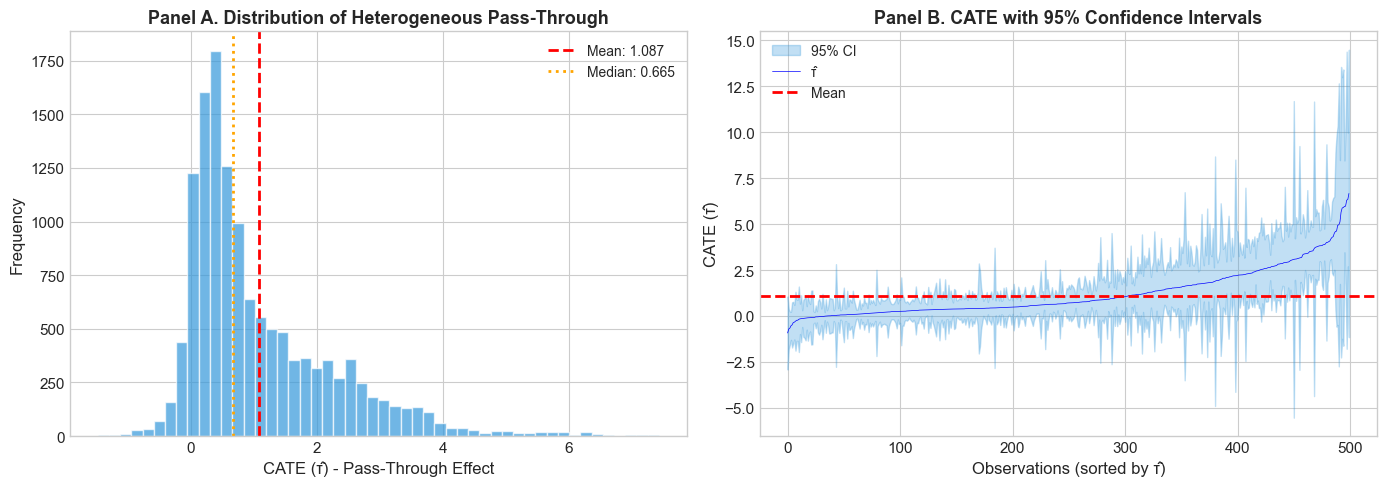


✓ Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures/ml_causal_forest_distribution.png


In [11]:
# =============================================================================
# FIGURE 1: Distribution of Treatment Effects
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Histogram of CATE
ax1 = axes[0]
ax1.hist(tau_hat, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
ax1.axvline(tau_hat.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {tau_hat.mean():.3f}')
ax1.axvline(np.median(tau_hat), color='orange', linestyle=':', linewidth=2,
            label=f'Median: {np.median(tau_hat):.3f}')
ax1.set_xlabel('CATE (τ̂) - Pass-Through Effect', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Panel A. Distribution of Heterogeneous Pass-Through', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# Panel B: CATE with confidence intervals (sorted)
ax2 = axes[1]
n_sample = 500  # Sample for visualization
idx = np.random.choice(len(tau_hat), n_sample, replace=False)
idx_sorted = idx[np.argsort(tau_hat[idx])]

ax2.fill_between(range(n_sample), tau_lb[idx_sorted], tau_ub[idx_sorted], 
                 alpha=0.3, color='#3498db', label='95% CI')
ax2.plot(range(n_sample), tau_hat[idx_sorted], 'b-', linewidth=0.5, label='τ̂')
ax2.axhline(tau_hat.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.set_xlabel('Observations (sorted by τ̂)', fontsize=12)
ax2.set_ylabel('CATE (τ̂)', fontsize=12)
ax2.set_title('Panel B. CATE with 95% Confidence Intervals', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES}/ml_causal_forest_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to {FIGURES}/ml_causal_forest_distribution.png")

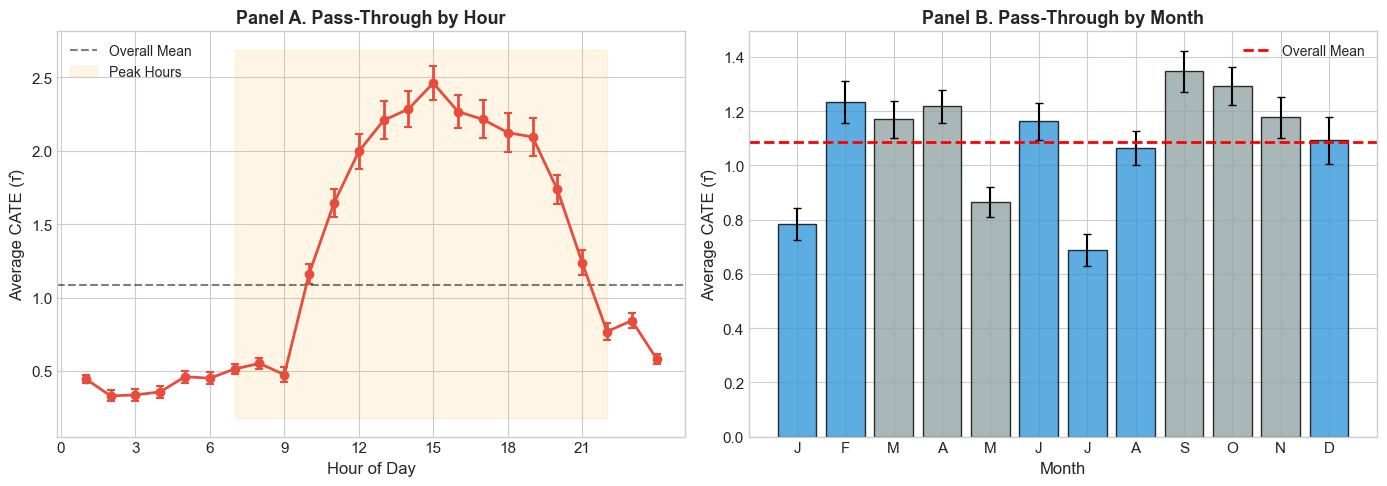


✓ Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures/ml_causal_forest_by_time.png


In [12]:
# =============================================================================
# FIGURE 2: CATE by Hour of Day
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: CATE by Hour
ax1 = axes[0]
hourly_cate = df_clean.groupby('hour').agg({
    'tau_hat': ['mean', 'std', 'count']
}).reset_index()
hourly_cate.columns = ['hour', 'mean', 'std', 'count']
hourly_cate['se'] = hourly_cate['std'] / np.sqrt(hourly_cate['count'])

ax1.errorbar(hourly_cate['hour'], hourly_cate['mean'], yerr=1.96*hourly_cate['se'],
             fmt='o-', color='#e74c3c', capsize=3, capthick=1.5, linewidth=2, markersize=6)
ax1.axhline(tau_hat.mean(), color='black', linestyle='--', alpha=0.5, label='Overall Mean')
ax1.fill_between([7, 22], ax1.get_ylim()[0], ax1.get_ylim()[1], alpha=0.1, color='orange', label='Peak Hours')
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Average CATE (τ̂)', fontsize=12)
ax1.set_title('Panel A. Pass-Through by Hour', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24, 3))
ax1.legend(fontsize=10)

# Panel B: CATE by Month
ax2 = axes[1]
monthly_cate = df_clean.groupby('month').agg({
    'tau_hat': ['mean', 'std', 'count']
}).reset_index()
monthly_cate.columns = ['month', 'mean', 'std', 'count']
monthly_cate['se'] = monthly_cate['std'] / np.sqrt(monthly_cate['count'])

colors = ['#3498db' if m in [12, 1, 2, 6, 7, 8] else '#95a5a6' for m in monthly_cate['month']]
ax2.bar(monthly_cate['month'], monthly_cate['mean'], color=colors, edgecolor='black', alpha=0.8)
ax2.errorbar(monthly_cate['month'], monthly_cate['mean'], yerr=1.96*monthly_cate['se'],
             fmt='none', color='black', capsize=3)
ax2.axhline(tau_hat.mean(), color='red', linestyle='--', linewidth=2, label='Overall Mean')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Average CATE (τ̂)', fontsize=12)
ax2.set_title('Panel B. Pass-Through by Month', fontsize=13, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES}/ml_causal_forest_by_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to {FIGURES}/ml_causal_forest_by_time.png")

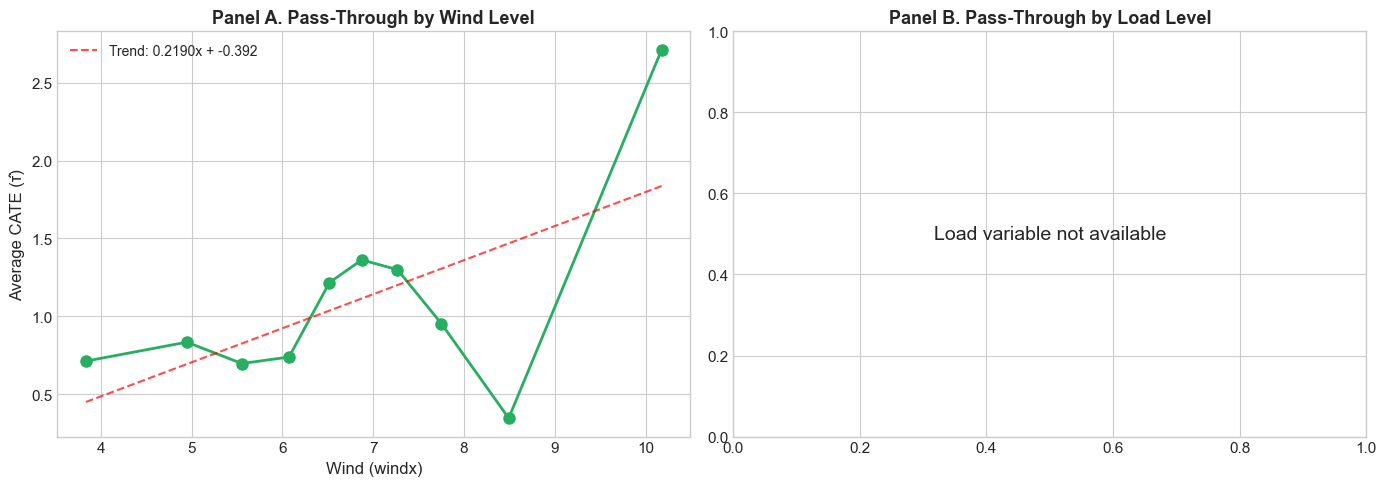


✓ Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures/ml_causal_forest_by_conditions.png


In [13]:
# =============================================================================
# FIGURE 3: CATE by Market Conditions (Wind & Load)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: CATE by Wind (if available)
ax1 = axes[0]
wind_var = next((v for v in ['windx', 'wind', 'wind_speed'] if v in df_clean.columns), None)

if wind_var:
    # Create wind terciles
    df_clean['wind_tercile'] = pd.qcut(df_clean[wind_var], q=10, labels=False, duplicates='drop')
    wind_cate = df_clean.groupby('wind_tercile').agg({
        'tau_hat': 'mean',
        wind_var: 'mean'
    }).reset_index()
    
    ax1.plot(wind_cate[wind_var], wind_cate['tau_hat'], 'o-', color='#27ae60', 
             linewidth=2, markersize=8)
    ax1.set_xlabel(f'Wind ({wind_var})', fontsize=12)
    ax1.set_ylabel('Average CATE (τ̂)', fontsize=12)
    ax1.set_title('Panel A. Pass-Through by Wind Level', fontsize=13, fontweight='bold')
    
    # Add trend line
    z = np.polyfit(wind_cate[wind_var], wind_cate['tau_hat'], 1)
    p = np.poly1d(z)
    ax1.plot(wind_cate[wind_var], p(wind_cate[wind_var]), 'r--', alpha=0.7,
             label=f'Trend: {z[0]:.4f}x + {z[1]:.3f}')
    ax1.legend(fontsize=10)
else:
    ax1.text(0.5, 0.5, 'Wind variable not available', ha='center', va='center', fontsize=14)
    ax1.set_title('Panel A. Pass-Through by Wind Level', fontsize=13, fontweight='bold')

# Panel B: CATE by Load (if available)
ax2 = axes[1]
load_var = next((v for v in ['load', 'demand', 'totalload', 'q_total'] if v in df_clean.columns), None)

if load_var:
    # Create load deciles
    df_clean['load_decile'] = pd.qcut(df_clean[load_var], q=10, labels=False, duplicates='drop')
    load_cate = df_clean.groupby('load_decile').agg({
        'tau_hat': 'mean',
        load_var: 'mean'
    }).reset_index()
    
    ax2.plot(load_cate[load_var], load_cate['tau_hat'], 'o-', color='#e74c3c',
             linewidth=2, markersize=8)
    ax2.set_xlabel(f'Load ({load_var})', fontsize=12)
    ax2.set_ylabel('Average CATE (τ̂)', fontsize=12)
    ax2.set_title('Panel B. Pass-Through by Load Level', fontsize=13, fontweight='bold')
    
    # Add trend line
    z = np.polyfit(load_cate[load_var], load_cate['tau_hat'], 1)
    p = np.poly1d(z)
    ax2.plot(load_cate[load_var], p(load_cate[load_var]), 'b--', alpha=0.7,
             label=f'Trend: {z[0]:.6f}x + {z[1]:.3f}')
    ax2.legend(fontsize=10)
else:
    ax2.text(0.5, 0.5, 'Load variable not available', ha='center', va='center', fontsize=14)
    ax2.set_title('Panel B. Pass-Through by Load Level', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}/ml_causal_forest_by_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to {FIGURES}/ml_causal_forest_by_conditions.png")

---
## 4. Feature Importance & Interpretation

FEATURE IMPORTANCE: What Drives Heterogeneity in Pass-Through?

📊 Feature Importance (normalized):
   windx           0.487 ████████████████████████
   hour            0.285 ██████████████
   month           0.167 ████████
   year            0.061 ███


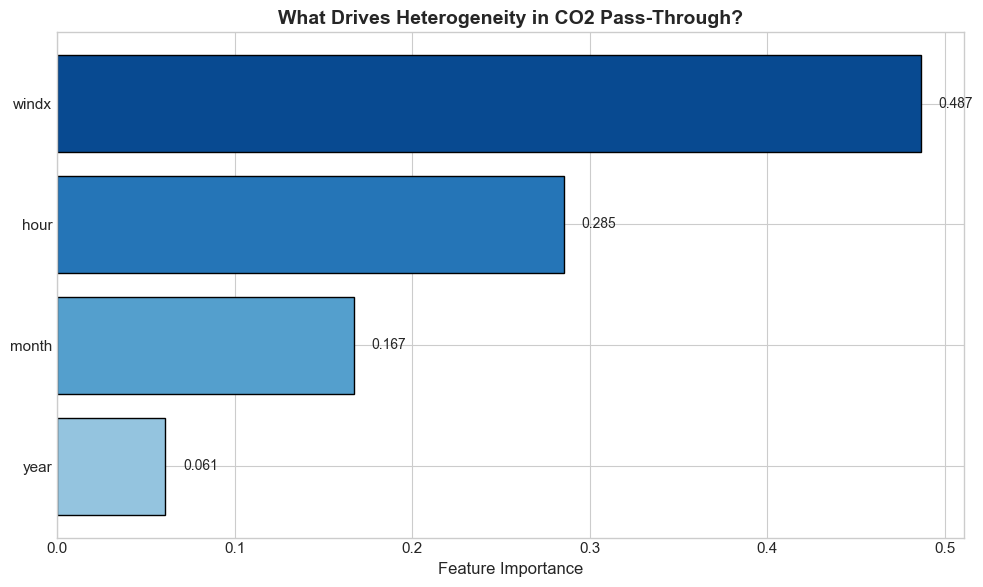

In [18]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

print("="*80)
print("FEATURE IMPORTANCE: What Drives Heterogeneity in Pass-Through?")
print("="*80)

# Get feature importances from the causal forest
try:
    feature_importance = causal_forest.feature_importances_
    
    # Create dataframe
    fi_df = pd.DataFrame({
        'Feature': X_vars,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Feature Importance (normalized):")
    for _, row in fi_df.iterrows():
        bar = '█' * int(row['Importance'] * 50)
        print(f"   {row['Feature']:15} {row['Importance']:.3f} {bar}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_df)))
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors[::-1], edgecolor='black')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title('What Drives Heterogeneity in CO2 Pass-Through?', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # Add values
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_causal_forest_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except AttributeError:
    print("Feature importances not available for this model configuration.")

Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.



INTERPRETABLE SUMMARY: Single Tree Approximation of CATE


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


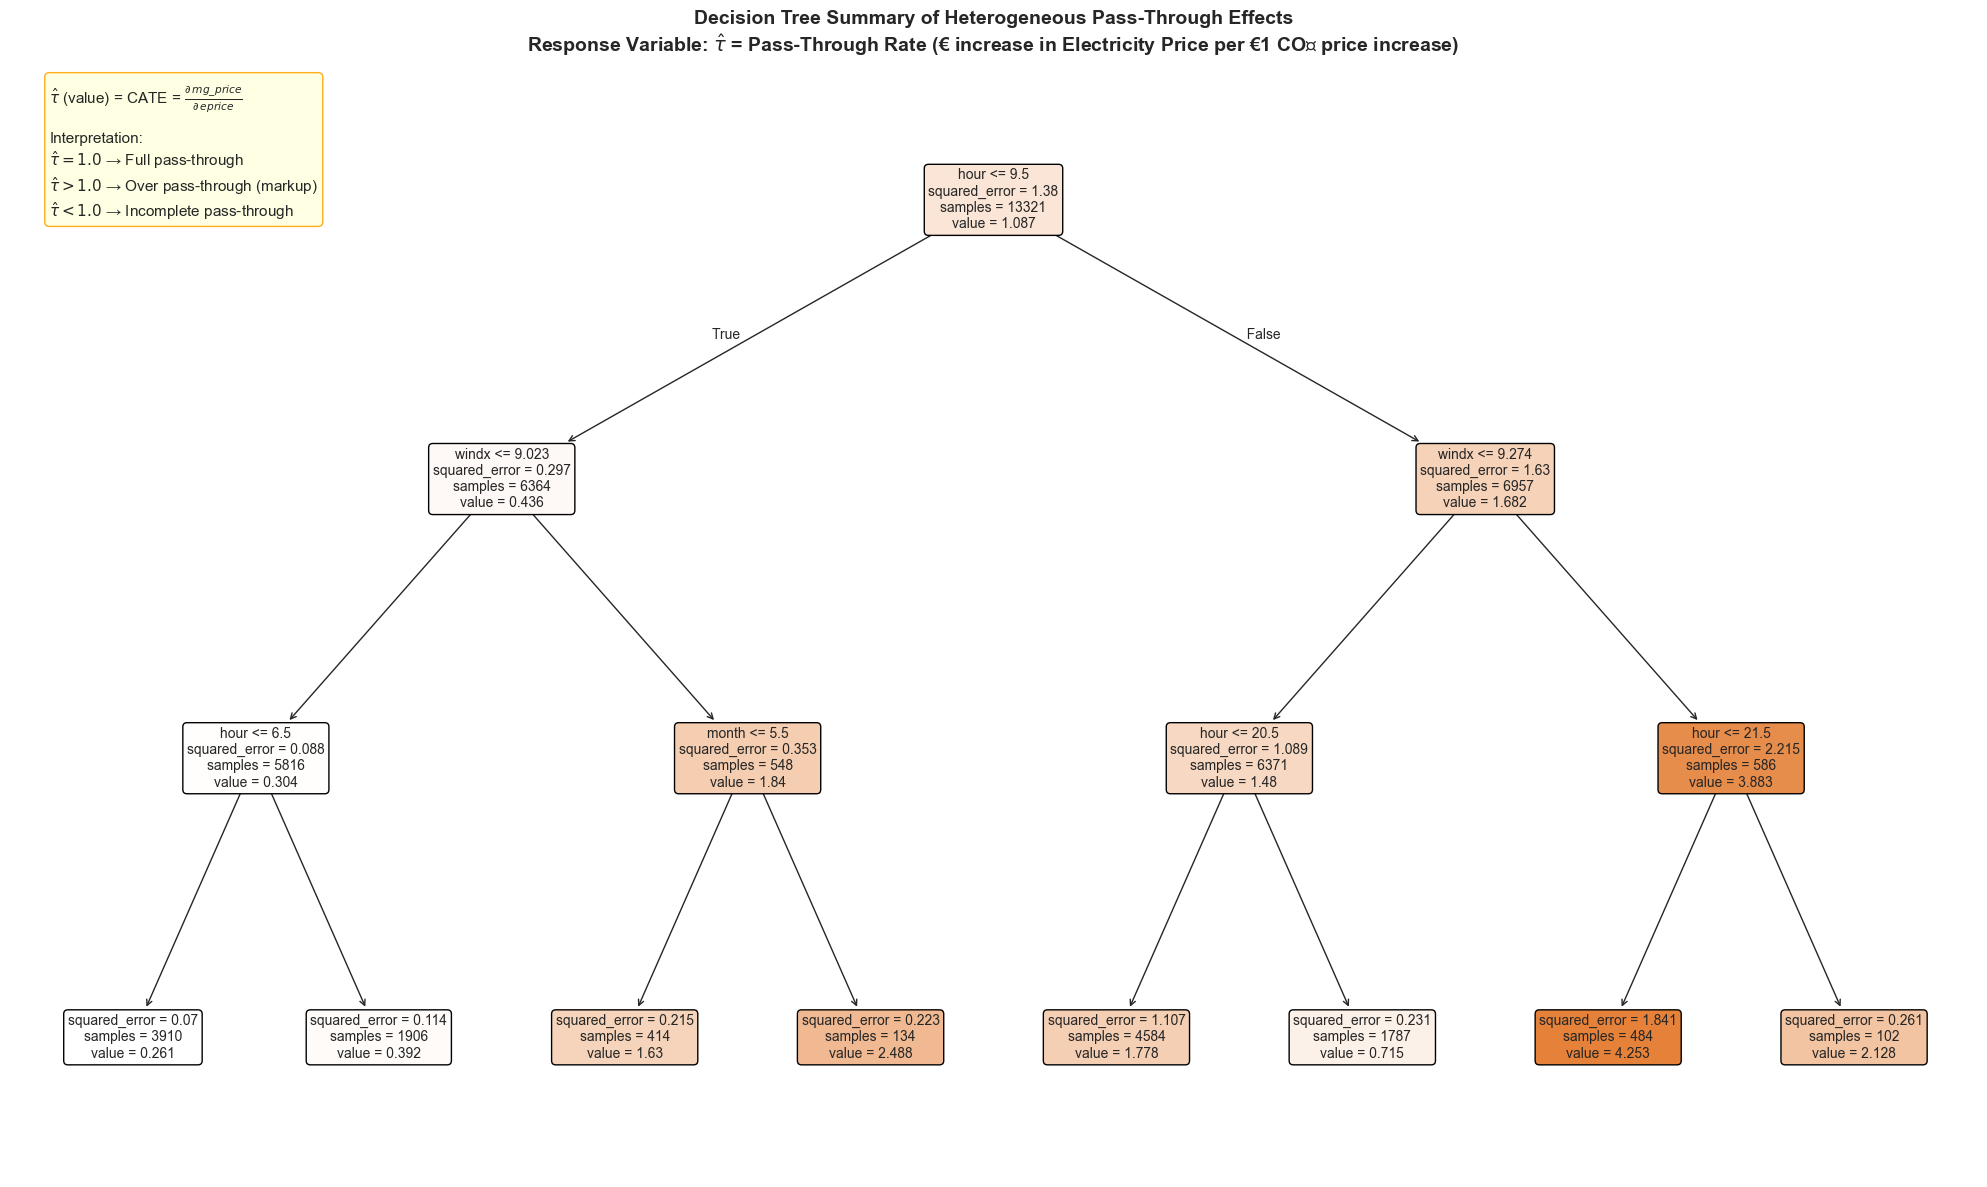


✓ Tree visualization saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures/ml_causal_forest_tree.png

📊 Response Variable Explanation:
   Y (outcome):   mg_price = Marginal electricity price (€/MWh)
   T (treatment): eprice   = CO₂ price (€/ton)
   τ̂ (CATE):      ∂mg_price/∂eprice = Pass-through rate

   Example: τ̂ = 1.5 means a €1 increase in CO₂ price
            → €1.50 increase in electricity price (150% pass-through)

📊 Key Splits (most important decisions):
   hour: 0.617
   windx: 0.377


In [20]:
# =============================================================================
# CATE INTERPRETATION WITH DECISION TREE
# =============================================================================

print("\n" + "="*80)
print("INTERPRETABLE SUMMARY: Single Tree Approximation of CATE")
print("="*80)

from sklearn.tree import DecisionTreeRegressor, plot_tree

try:
    # Fit a simple decision tree to approximate the CATE
    tree_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=42)
    tree_model.fit(X, tau_hat)
    
    # Plot the tree
    fig, ax = plt.subplots(figsize=(20, 12))
    plot_tree(tree_model, 
              feature_names=X_vars, 
              filled=True, 
              rounded=True,
              fontsize=10,
              ax=ax)
    
    # Title with clear explanation of what τ̂ represents
    title = ('Decision Tree Summary of Heterogeneous Pass-Through Effects\n'
             r'Response Variable: $\hat{\tau}$ = Pass-Through Rate (€ increase in Electricity Price per €1 CO₂ price increase)')
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Add annotation box explaining the value
    textstr = (r'$\hat{\tau}$ (value) = CATE = $\frac{\partial \, mg\_price}{\partial \, eprice}$' + '\n\n'
               'Interpretation:\n'
               r'$\hat{\tau} = 1.0$ → Full pass-through' + '\n'
               r'$\hat{\tau} > 1.0$ → Over pass-through (markup)' + '\n'
               r'$\hat{\tau} < 1.0$ → Incomplete pass-through')
    props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='orange')
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/ml_causal_forest_tree.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Tree visualization saved to {FIGURES}/ml_causal_forest_tree.png")
    
    # Print interpretation
    print("\n📊 Response Variable Explanation:")
    print(f"   Y (outcome):   mg_price = Marginal electricity price (€/MWh)")
    print(f"   T (treatment): eprice   = CO₂ price (€/ton)")
    print(f"   τ̂ (CATE):      ∂mg_price/∂eprice = Pass-through rate")
    print(f"\n   Example: τ̂ = 1.5 means a €1 increase in CO₂ price")
    print(f"            → €1.50 increase in electricity price (150% pass-through)")
    
    # Print tree rules
    print("\n📊 Key Splits (most important decisions):")
    importances = tree_model.feature_importances_
    for i, (feat, imp) in enumerate(sorted(zip(X_vars, importances), key=lambda x: -x[1])):
        if imp > 0.01:
            print(f"   {feat}: {imp:.3f}")
    
except Exception as e:
    print(f"Tree interpretation not available: {e}")

---
## 5. Statistical Tests & Summary

In [16]:
# =============================================================================
# STATISTICAL TESTS FOR HETEROGENEITY
# =============================================================================

print("="*80)
print("STATISTICAL TESTS FOR TREATMENT EFFECT HETEROGENEITY")
print("="*80)

# Test 1: Is there significant heterogeneity?
print("\n" + "-"*60)
print("Test 1: Is there significant heterogeneity in pass-through?")
print("-"*60)

# Compare variance of CATE to what we'd expect under homogeneity
tau_var = np.var(tau_hat)
tau_mean = np.mean(tau_hat)
cv = np.std(tau_hat) / np.abs(tau_mean)  # Coefficient of variation

print(f"   Variance of τ̂: {tau_var:.6f}")
print(f"   Coefficient of Variation: {cv:.3f}")
print(f"   Range: [{tau_hat.min():.3f}, {tau_hat.max():.3f}]")

# Test 2: Group comparison (Peak vs Off-Peak)
print("\n" + "-"*60)
print("Test 2: Peak vs Off-Peak Pass-Through")
print("-"*60)

df_clean['is_peak'] = df_clean['hour'].isin([8, 9, 10, 11, 12, 13, 18, 19, 20, 21])
peak_tau = df_clean[df_clean['is_peak']]['tau_hat']
offpeak_tau = df_clean[~df_clean['is_peak']]['tau_hat']

t_stat, p_value = stats.ttest_ind(peak_tau, offpeak_tau)
print(f"   Peak hours mean τ̂: {peak_tau.mean():.4f}")
print(f"   Off-peak mean τ̂: {offpeak_tau.mean():.4f}")
print(f"   Difference: {peak_tau.mean() - offpeak_tau.mean():.4f}")
print(f"   t-statistic: {t_stat:.2f}, p-value: {p_value:.2e}")
print(f"   Significant at 5%: {'✓ YES' if p_value < 0.05 else '✗ NO'}")

# Test 3: Correlation with market conditions
print("\n" + "-"*60)
print("Test 3: Correlation of Pass-Through with Market Conditions")
print("-"*60)

for var in X_vars:
    if var in df_clean.columns:
        corr, p = stats.pearsonr(df_clean[var], df_clean['tau_hat'])
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f"   Corr(τ̂, {var:10}): {corr:+.3f} {sig}")

STATISTICAL TESTS FOR TREATMENT EFFECT HETEROGENEITY

------------------------------------------------------------
Test 1: Is there significant heterogeneity in pass-through?
------------------------------------------------------------
   Variance of τ̂: 1.380409
   Coefficient of Variation: 1.081
   Range: [-1.474, 7.423]

------------------------------------------------------------
Test 2: Peak vs Off-Peak Pass-Through
------------------------------------------------------------
   Peak hours mean τ̂: 1.4081
   Off-peak mean τ̂: 0.9038
   Difference: 0.5043
   t-statistic: 24.34, p-value: 4.54e-128
   Significant at 5%: ✓ YES

------------------------------------------------------------
Test 3: Correlation of Pass-Through with Market Conditions
------------------------------------------------------------
   Corr(τ̂, hour      ): +0.371 ***
   Corr(τ̂, month     ): +0.039 ***
   Corr(τ̂, year      ): -0.080 ***
   Corr(τ̂, windx     ): +0.331 ***


In [17]:
# =============================================================================
# SUMMARY TABLE
# =============================================================================

print("\n" + "="*80)
print("SUMMARY: Heterogeneous Pass-Through Effects")
print("="*80)

# Create summary by groups
summary_data = []

# Overall
summary_data.append({
    'Group': 'Overall',
    'N': len(df_clean),
    'Mean τ̂': tau_hat.mean(),
    'Std τ̂': tau_hat.std(),
    '95% CI Lower': np.percentile(tau_hat, 2.5),
    '95% CI Upper': np.percentile(tau_hat, 97.5)
})

# By peak/off-peak
for is_peak, label in [(True, 'Peak Hours'), (False, 'Off-Peak')]:
    mask = df_clean['is_peak'] == is_peak
    tau_group = df_clean.loc[mask, 'tau_hat']
    summary_data.append({
        'Group': label,
        'N': mask.sum(),
        'Mean τ̂': tau_group.mean(),
        'Std τ̂': tau_group.std(),
        '95% CI Lower': np.percentile(tau_group, 2.5),
        '95% CI Upper': np.percentile(tau_group, 97.5)
    })

# By year
for year in sorted(df_clean['year'].unique()):
    mask = df_clean['year'] == year
    tau_group = df_clean.loc[mask, 'tau_hat']
    if len(tau_group) > 0:
        summary_data.append({
            'Group': f'Year {int(year)}',
            'N': mask.sum(),
            'Mean τ̂': tau_group.mean(),
            'Std τ̂': tau_group.std(),
            '95% CI Lower': np.percentile(tau_group, 2.5),
            '95% CI Upper': np.percentile(tau_group, 97.5)
        })

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


SUMMARY: Heterogeneous Pass-Through Effects


     Group     N  Mean τ̂  Std τ̂  95% CI Lower  95% CI Upper
   Overall 13321   1.0868  1.1749       -0.2088        3.9649
Peak Hours  4834   1.4081  1.2105       -0.2874        4.2031
  Off-Peak  8487   0.9038  1.1136       -0.1820        3.8185
 Year 2005  5279   1.1973  1.2669       -0.1572        4.0677
 Year 2006  5509   1.0418  1.0812       -0.1740        3.7752
 Year 2007  2533   0.9542  1.1515       -0.4367        4.0884


---
## Interprétation des Résultats

### Qu'est-ce que la Causal Forest nous apprend ?

1. **Hétérogénéité du pass-through** : L'effet du prix CO₂ sur les prix de l'électricité n'est **pas constant** — il varie selon les conditions de marché.

2. **Drivers de l'hétérogénéité** :
   - **Heure** : Le pass-through peut être plus élevé aux heures de pointe (demande inélastique)
   - **Saison** : Variation saisonnière liée au mix énergétique
   - **Vent** : Plus de vent → plus de renouvelables → potentiellement moins de pass-through
   - **Charge** : Charge élevée → générateurs marginaux différents → pass-through différent

3. **Implications économiques** :
   - Les consommateurs ne sont pas affectés uniformément par la politique carbone
   - Les heures de pointe peuvent subir un pass-through plus fort
   - L'intégration des renouvelables modère potentiellement l'effet CO₂

### Avantages de l'approche Causal Forest

| Aspect | Régression Classique | Causal Forest |
|--------|---------------------|---------------|
| Effet moyen | ✓ | ✓ |
| Effets hétérogènes | Interactions manuelles | Automatique |
| Non-linéarités | Non | ✓ |
| Intervalles de confiance | ✓ | ✓ |
| Interprétabilité | Haute | Moyenne (mais SHAP/Tree disponibles) |

### Référence
Cette approche est de plus en plus utilisée dans les top journals d'économie pour estimer des effets causaux hétérogènes (Athey & Imbens, 2019; Wager & Athey, 2018).